<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Logistic%20Regression/Heart_failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import warnings

warnings.filterwarnings("ignore")

In [28]:
import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


In [29]:
import pandas as pd

df = pd.read_csv("/kaggle/input/heart-failure-prediction/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [30]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [31]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [32]:
df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [33]:
df['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

In [34]:
df['ExerciseAngina'].unique()

array(['N', 'Y'], dtype=object)

In [35]:
df['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

In [36]:
label = df['HeartDisease']
label

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
913,1
914,1
915,1
916,1


In [37]:
y = label.values
y[:10]

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0])

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [39]:
categorical_cols = ['ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
numerical_cols = ['Age','RestingBP','Cholesterol','FastingBS', 'MaxHR', 'Oldpeak']
categorical_cols, numerical_cols

(['ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'],
 ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'])

In [40]:
ct = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorical_cols),
    ('numerical', StandardScaler(), numerical_cols)
])

In [41]:
ct

ColumnTransformer(transformers=[('categorical', OneHotEncoder(),
                                 ['ChestPainType', 'RestingECG',
                                  'ExerciseAngina', 'ST_Slope']),
                                ('numerical', StandardScaler(),
                                 ['Age', 'RestingBP', 'Cholesterol',
                                  'FastingBS', 'MaxHR', 'Oldpeak'])])

In [42]:
ct_transformed = ct.fit_transform(df)

In [43]:
ct_transformed

array([[ 0.        ,  1.        ,  0.        , ..., -0.55134134,
         1.38292822, -0.83243239],
       [ 0.        ,  0.        ,  1.        , ..., -0.55134134,
         0.75415714,  0.10566353],
       [ 0.        ,  1.        ,  0.        , ..., -0.55134134,
        -1.52513802, -0.83243239],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -0.55134134,
        -0.85706875,  0.29328271],
       [ 0.        ,  1.        ,  0.        , ..., -0.55134134,
         1.4615246 , -0.83243239],
       [ 0.        ,  0.        ,  1.        , ..., -0.55134134,
         1.42222641, -0.83243239]])

In [23]:
len(ct_transformed)

918

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(ct_transformed, y, test_size=0.2)
len(X_train), len(X_test)

(734, 184)

In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [46]:
model.score(X_test, y_test)

0.8641304347826086

              precision    recall  f1-score   support

           0       0.78      0.90      0.84        72
           1       0.93      0.84      0.88       112

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.87       184



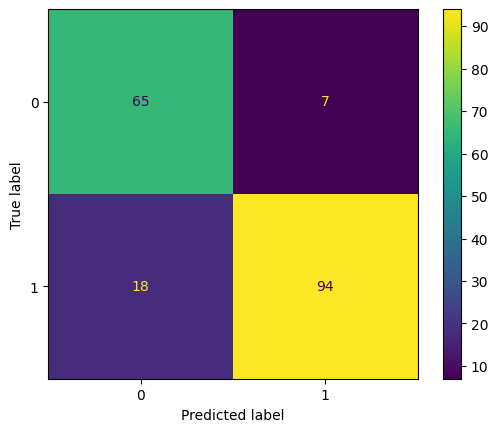

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred = model.predict(X_test)
cr = classification_report(pred, y_test)
cm = confusion_matrix(pred, y_test)
print(cr)
ConfusionMatrixDisplay(cm).plot()
plt.show()